
# 1 — Squeezing sources: discovery + construction rules

AutoGaussian runs [AUTOSCATTER](https://github.com/jlandgr/autoscatter)'s discrete +
continuous discovery loop on a **second-moment** target — the output covariance
$\sigma_\mathrm{out}(\Omega)$ — instead of a scattering matrix $S$.

This notebook covers:

* **B.1** — single-mode squeezer (validation)
* **B.2** — EPR / two-mode-squeezed source
* **Sec. 7.2** — closed-form construction rules

Script version: `examples/01_discover_squeezers.py`.


In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from autogaussian import (
    CovarianceArchitectureOptimizer,
    CovarianceTarget,
    discover,
    plot_list_of_graphs,
    solution_table,
    variance_to_dB,
)
from autogaussian.gallery import epr_source, single_mode_squeezer
from autogaussian.postprocess import symbolic_regression

# --- collective dissipative channels (COLLECTIVE_CHANNELS_ADDENDUM) --------
# The dissipative scaffold is a second, searchable graph: each channel is a
# hyperedge over modes, tagged (class, access).  A private channel is the
# support-1 corner, so the base spec is the diagonal of this search space.
from autogaussian.certificates import pbh_dark_mode_collective
from autogaussian.channels import Access, ChannelClass
from autogaussian.collective_oracle import (
    CollectiveArchitectureOptimizer,
    collective_cooperativities,
)
from autogaussian.hypergraph import collective_usage_report
from autogaussian.search import (
    discover as two_library_discover,
    revalidate_valid_library,
)

## B.1 — single-mode squeezer

$$\sigma_\mathrm{target} = \begin{pmatrix} 0.5 & 0 \\ 0 & 2.0\end{pmatrix}$$

3 dB of squeezing in $x$. The conjugate quadrature is pinned to $1/v$, so the
emitted state is **pure**.

Run here on the **collective-channel** engine, where the damping is searchable:
the scalars $\sqrt{\kappa}, \sqrt{\Gamma}$ are promoted to coupling matrices
$\mathcal{K}_\kappa, \mathcal{K}_\Gamma$, and the search decides which modes share
which channel.

One mode has no subsets of size $\ge 2$, so there is nothing to share and the
hypergraph degenerates to the private scaffold. That makes B.1 the **reduction
test**: the collective engine must return exactly what the base algorithm returns.


In [3]:
problem = single_mode_squeezer(variance=0.5)
print(problem.target)

optimizer = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=0, seed=0, make_initial_test=False,
    **problem.optimizer_kwargs())

print("\ndissipative colour -- the candidate channels the search may switch on:")
for slot in optimizer.space.channels.channel_slots:
    print("   ", slot)

libraries = two_library_discover(optimizer, progress=False, verbose=False,
                                 use_certificates=True)
irreducibles = libraries.minimal_valid()
print("\n" + libraries.summary())
# Invariant 4 says VALID means a witness exists *and is stored*.  Nothing
# re-checks that once an entry lands, and the graph-reduction step can store a
# reduced graph the witness does not actually satisfy.  Audit the deliverable.
failures = revalidate_valid_library(optimizer, libraries, verbose=True)
print("audit: %d of the irreducibles fail the stored-witness check"
      % len(failures))

CovarianceTarget(single-mode squeezer, 1 ports, 3 pins)
  sigma_out[0,0](Omega=0) = 0.5   (w=1, full)
  sigma_out[0,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,1](Omega=0) = 2.0   (w=1, full)



dissipative colour -- the candidate channels the search may switch on:
    ChannelSlot([0], particle_conserving, controlled)
    ChannelSlot([0], particle_conserving, uncontrolled)



valid: 6    invalid: 11 (certified 1, uncertified 10)    oracle calls: 206    escalations: 10
audit: 0 of the irreducibles fail the stored-witness check


In [4]:
for graph in irreducibles:
    print("  ", ", ".join(optimizer.space.describe(graph)))
print()
print(libraries.completeness_statement(optimizer.space))

   on-site squeezing 0 (complex), private controlled particle_conserving channel on [0] (real)
   detuning Delta_0, on-site squeezing 0 (real), private controlled particle_conserving channel on [0] (real)

The list of irreducible graphs is complete up to at most 10 false negatives (graphs rejected without a certificate):
    [default] detuning Delta_0, on-site squeezing 0 (complex), private uncontrolled particle_conserving channel on [0] (real)
    [default] on-site squeezing 0 (real), private controlled particle_conserving channel on [0] (real), private uncontrolled particle_conserving channel on [0] (real)
    [default] on-site squeezing 0 (complex), private uncontrolled particle_conserving channel on [0] (real)
    [default] detuning Delta_0, on-site squeezing 0 (real), private uncontrolled particle_conserving channel on [0] (real)
    [default] detuning Delta_0, on-site squeezing 0 (complex)
    [default] on-site squeezing 0 (real), private uncontrolled particle_conserving channel 

The same list with the *solutions* attached — what a hardware implementation has
to dial in, now including the jump amplitudes $u_{\mu i}$.

**Read cooperativities, not rates.** The collected rate is a free channel
amplitude here rather than pinned to 1, so the forward map carries a scale gauge
$(H,\mathcal{K})\to(sH,s\mathcal{K})$. $\kappa$ comes out far from 1, but the
dimensionless $C_{00}$ still lands on the Sec. 7.2 construction rule.


In [5]:
analytic = ((1 - np.sqrt(0.5)) / (1 + np.sqrt(0.5))) ** 2

for graph in irreducibles:
    solution = optimizer.solution_of(graph)
    if solution is None:
        print(", ".join(optimizer.space.describe(graph)), "-- no stored witness")
        continue
    x = solution["x"]
    V = np.real(np.asarray(optimizer.oracle.covariance(x, 0.0)))
    channels = optimizer.param.channel_set(graph, x)
    nu = np.asarray(optimizer.param.coherent.blocks(x)[1])[0, 0]
    kappa = abs(channels.controlled[0].u[0]) ** 2

    print(", ".join(optimizer.space.describe(graph)))
    print("   sigma_out(0) =",
          np.array2string(V, precision=6, suppress_small=True).replace("\n", "\n                 "))
    print("   loss %.2e    alpha %+.4f"
          % (solution["loss_reached"], solution["max_real_eigenvalue"]))
    for channel in channels:
        print("   %-46s u = %s" % (channel, np.array2string(channel.u, precision=5)))
    print("   |nu| = %.6f   kappa = |u|^2 = %.6f   C_00 = 4|nu/kappa|^2 = %.6f"
          % (abs(nu), kappa, 4 * abs(nu / kappa) ** 2))
    print("   private sufficed:",
          collective_usage_report(optimizer.space, graph, channels)["private_sufficed"])
    print()

print("analytic  C_00(v=0.5) = ((1 - sqrt v)/(1 + sqrt v))^2 = %.6f" % analytic)

on-site squeezing 0 (complex), private controlled particle_conserving channel on [0] (real)
   sigma_out(0) = [[0.499999 0.000004]
                  [0.000004 2.000004]]
   loss 1.71e-11    alpha -0.8606
   controlled particle_conserving support=[0]     u = [1.44139+0.j]
   |nu| = 0.178231   kappa = |u|^2 = 2.077603   C_00 = 4|nu/kappa|^2 = 0.029437
   private sufficed: True

detuning Delta_0, on-site squeezing 0 (real), private controlled particle_conserving channel on [0] (real)
   sigma_out(0) = [[ 0.5      -0.      ]
                  [-0.        1.999998]]
   loss 1.76e-12    alpha -0.6438
   controlled particle_conserving support=[0]     u = [1.13475+0.j]
   |nu| = 0.227626   kappa = |u|^2 = 1.287648   C_00 = 4|nu/kappa|^2 = 0.125000
   private sufficed: True

analytic  C_00(v=0.5) = ((1 - sqrt v)/(1 + sqrt v))^2 = 0.029437


The irreducible devices, drawn as graphs:

* black edge — real beam-splitter
* green edge — complex beam-splitter (synthetic flux)
* blue edge — squeezing
* square node — carries on-site squeezing
* thick border — detuned mode

Only the **coherent** colour is drawn. The dissipative colour of each graph is
listed above; for one mode it is a single private collected channel, which the
base spec hard-wired rather than searched.


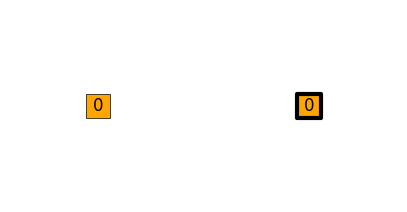

In [6]:
coherent_halves = np.array([optimizer.space.split(g)[0] for g in irreducibles],
                           dtype="int8")
fig, axes = plot_list_of_graphs(coherent_halves, optimizer.space.coherent,
                                node_colors=["orange"] * optimizer.space.num_modes)
plt.show()

### What changes once $\kappa$ is searchable

The base spec hard-wired $\kappa_i=1$ on *every* mode, so it could never propose a
device with an undamped mode. Now that the collected rate is a channel amplitude
it can — and the PBH dark-mode certificate has real work to do.

The test: give B.1 one auxiliary mode and leave it untouched by every channel.
The fit still lands on the target, but the device is rejected — its spectral
abscissa sits exactly at zero.

Reaching that mode with **either** a private or a collective channel repairs it,
and the engine reports which one the fit actually used.


In [7]:
aux = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=0, make_initial_test=False,
    kwargs_optimization={"num_tests": 20}, **problem.optimizer_kwargs())

space = aux.space
offset = space.num_coherent_slots
onsite = space.coherent.slots.index(("onsite_squeezing", 0, 0))
port0 = space.channels.index_of((0,), ChannelClass.PARTICLE_CONSERVING, Access.CONTROLLED)
port1 = space.channels.index_of((1,), ChannelClass.PARTICLE_CONSERVING, Access.CONTROLLED)
shared = space.channels.index_of((0, 1), ChannelClass.PARTICLE_CONSERVING, Access.CONTROLLED)

def make(extra=None, value=2):
    graph = space.empty()
    graph[onsite] = 2
    graph[offset + port0] = 1
    if extra is not None:
        graph[offset + extra] = value
    return graph

cases = [("private on mode 0 only", make()),
         ("+ collective channel (0,1)", make(shared)),
         ("+ private channel on mode 1", make(port1, value=1))]

print("%-30s %-6s %-11s %-9s %-14s %s"
      % ("channels", "valid", "fit loss", "alpha", "PBH dark mode", "verdict"))
for label, graph in cases:
    ok, infos = aux.test_graph(graph)
    best = min(infos, key=lambda info: info["loss_reached"])
    alpha = min(info["max_real_eigenvalue"] for info in infos)
    H_bdg = aux.param.hamiltonian(best["x"])
    channels = aux.param.channel_set(graph, best["x"], drop_inactive=False)
    fired, _ = pbh_dark_mode_collective(H_bdg, channels)

    verdict = "VALID" if ok else "INVALID"
    if ok:
        witness = next(info for info in infos if info["success"])
        report = collective_usage_report(
            space, graph, aux.param.channel_set(graph, witness["x"]))
        verdict += ("  (private sufficed)" if report["private_sufficed"]
                    else "  (used the shared channel)")
    print("%-30s %-6s %.2e   %+.4f   %-14s %s"
          % (label, ok, best["loss_reached"], alpha,
             "FIRES" if fired else "clear", verdict))

channels                       valid  fit loss    alpha     PBH dark mode  verdict


private on mode 0 only         False  4.66e-14   +0.0000   FIRES          INVALID
+ collective channel (0,1)     True   1.71e-14   -0.8371   clear          VALID  (used the shared channel)


+ private channel on mode 1    True   9.79e-13   -0.4397   clear          VALID  (private sufficed)


Both repairs work, and the private one is reported as sufficient: B.1 gives a
shared channel nothing to do.

Private-vs-collective is *discovered*, not assumed — the addendum's claim working
as designed.



## Sec. 7.2 — construction rule $C_{00}(v)$

Sweep the squeezed-quadrature target $v$ over a range and fit the cooperativity
that realises it. The analytic reference is

$$C_{00}(v) = \left(\frac{1-\sqrt{v}}{1+\sqrt{v}}\right)^{2}.$$


In [8]:
v = sp.Symbol("v", positive=True)
target = CovarianceTarget(num_ports=1, name="squeezer with free depth")
target.pin((0, 0), v)          # squeezed quadrature -- the swept parameter
target.pin((1, 1), 1 / v)      # pure state
target.pin((0, 1), 0.0)

optimizer_rules = CovarianceArchitectureOptimizer(
    target, num_auxiliary_modes=0, optimize_gauge=False, make_initial_test=False,
    seed=0)
graph = optimizer_rules.space.empty()
graph[optimizer_rules.space.slots.index(("onsite_squeezing", 0, 0))] = 2

rules = symbolic_regression(optimizer_rules, graph, v, np.linspace(0.05, 0.95, 19))
print("swept %i target values" % len(rules["sweep"]))
for name, (model, expression, rmse) in rules["rules"].items():
    print("   %-14s = %s        [%s, rmse %.1e]" % (name, expression, model, rmse))
print("\n   analytic reference:  C_00(v) = ((1 - sqrt(v)) / (1 + sqrt(v)))^2")

swept 19 target values
   C_{0,0}        = 1.000009*(sqrt(t) - 1.0)**2/(sqrt(t) + 1.000005)**2        [sqrt_rational_squared, rmse 8.9e-08]
   arg(nu_{0,0})  = -1.57079600000000        [quadratic, rmse 2.8e-07]
   kappa~_0       = 1.00000000000000        [constant, rmse 0.0e+00]

   analytic reference:  C_00(v) = ((1 - sqrt(v)) / (1 + sqrt(v)))^2



Fitted rule against the analytic curve:

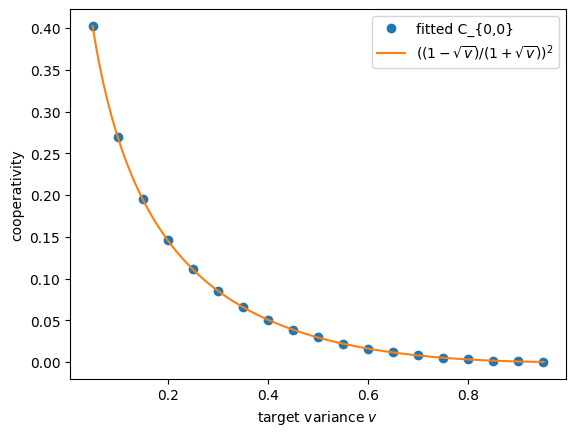

In [9]:
sweep = np.asarray(rules["sweep"], dtype=float)
name = "C_{0,0}"
values = np.asarray(rules["dataset"][name], dtype=float)

grid = np.linspace(0.05, 0.95, 200)
analytic = ((1 - np.sqrt(grid)) / (1 + np.sqrt(grid))) ** 2

plt.plot(sweep, values, "o", label="fitted %s" % name)
plt.plot(grid, analytic, "-", label=r"$((1-\sqrt{v})/(1+\sqrt{v}))^2$")
plt.xlabel(r"target variance $v$")
plt.ylabel("cooperativity")
plt.legend()
plt.show()

## B.2 — EPR source

Local variance 1.25 at each port and $\pm 0.75$ correlations — a Duan sum of 1.0,
well below the separability bound of 2.

Two modes, so for the first time a **shared** dissipative channel exists: the
search may put both ports on one common bath instead of two private ones. Whether
it does is the question, not the assumption.


In [10]:
problem = epr_source(local=1.25, correlation=0.75)
print(problem.target)

# Lean dissipative colour: the two collected ports plus the one channel they could
# share.  No intrinsic-loss channels (the target is pure) and no free phase on the
# shared channel.  That holds the two-coloured lattice at 2592 graphs instead of
# ~10^5, which is what makes a *complete* descent affordable -- and a complete
# descent is the point: minimal_valid() is meaningless if the BFS is cut off
# before it reaches the bottom.
epr_channels = dict(max_support=2, private_uncontrolled=False, allow_phases=False)

optimizer_epr = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=0, seed=2, make_initial_test=False,
    channel_kwargs=epr_channels, kwargs_optimization={"num_tests": 5},
    **problem.optimizer_kwargs())

print("\ntwo-coloured lattice: %d graphs" % optimizer_epr.space.num_possible_graphs())
libraries_epr = two_library_discover(optimizer_epr, progress=False, verbose=False,
                                     use_certificates=True)
irreducibles_epr = libraries_epr.minimal_valid()
print(libraries_epr.summary())
# Invariant 4 says VALID means a witness exists *and is stored*.  Nothing
# re-checks that once an entry lands, and the graph-reduction step can store a
# reduced graph the witness does not actually satisfy.  Audit the deliverable.
failures = revalidate_valid_library(optimizer_epr, libraries_epr, verbose=True)
print("audit: %d of the irreducibles fail the stored-witness check"
      % len(failures))

CovarianceTarget(EPR source, 2 ports, 16 pins)
  sigma_out[0,0](Omega=0) = 1.25   (w=1, full)
  sigma_out[0,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[0,2](Omega=0) = 0.75   (w=1, full)
  sigma_out[0,3](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,1](Omega=0) = 1.25   (w=1, full)
  sigma_out[1,2](Omega=0) = 0.0   (w=1, full)
  sigma_out[1,3](Omega=0) = -0.75   (w=1, full)
  sigma_out[2,0](Omega=0) = 0.75   (w=1, full)
  sigma_out[2,1](Omega=0) = 0.0   (w=1, full)
  sigma_out[2,2](Omega=0) = 1.25   (w=1, full)
  sigma_out[2,3](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,1](Omega=0) = -0.75   (w=1, full)
  sigma_out[3,2](Omega=0) = 0.0   (w=1, full)
  sigma_out[3,3](Omega=0) = 1.25   (w=1, full)

two-coloured lattice: 2592 graphs


valid: 76    invalid: 2116 (certified 1, uncertified 2115)    oracle calls: 21297    escalations: 2119
audit: 0 of the irreducibles fail the stored-witness check


In [11]:
for graph in irreducibles_epr:
    print("[%d elements] %s" % (graph.sum(), ", ".join(optimizer_epr.space.describe(graph))))

best_epr = irreducibles_epr[0]
solution_epr = optimizer_epr.solution_of(best_epr)
V = np.real(np.asarray(optimizer_epr.oracle.covariance(solution_epr["x"], 0.0)))
print("\nsigma_out at the two ports:")
print(np.round(V, 4))

# duan_sum uses the vacuum-floor-1 convention, where the separability bound is 4;
# the gallery quotes the halved convention, bound 2.  Print the halved one.
from autogaussian.nambu import duan_sum
print("Duan sum = %.4f   (halved convention; separability bound 2)"
      % (0.5 * duan_sum(V, 0, 1)))

[4 elements] two-mode squeezing 0-1 (complex), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
[5 elements] beam-splitter 0-1 (real), on-site squeezing 0 (real), on-site squeezing 1 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
[5 elements] detuning Delta_0, detuning Delta_1, two-mode squeezing 0-1 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)



sigma_out at the two ports:
[[ 1.25 -0.    0.75  0.  ]
 [-0.    1.25  0.   -0.75]
 [ 0.75  0.    1.25  0.  ]
 [ 0.   -0.75  0.    1.25]]
Duan sum = 1.0000   (halved convention; separability bound 2)


Did the shared channel earn its place? `collective_usage_report` answers per
architecture.

A shared channel that the fit drove to support-1, or to zero amplitude, is the
engine reporting that the local scaffold sufficed.


In [12]:
for graph in irreducibles_epr:
    solution = optimizer_epr.solution_of(graph)
    if solution is None:
        continue
    channels = optimizer_epr.param.channel_set(graph, solution["x"])
    report = collective_usage_report(optimizer_epr.space, graph, channels)
    print(", ".join(optimizer_epr.space.describe(graph)))
    for channel in channels:
        print("     %-46s u = %s" % (channel, np.array2string(channel.u, precision=5)))
    print("     private sufficed: %s   (collective channels used: %d)"
          % (report["private_sufficed"], report["num_collective_used"]))
    print("     %s" % {k: "%.4g" % v for k, v in
                       collective_cooperativities(optimizer_epr, graph,
                                                  solution["x"])["cooperativities"].items()})
    print()

two-mode squeezing 0-1 (complex), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
     controlled particle_conserving support=[0]     u = [3.18859+0.j 0.     +0.j]
     controlled particle_conserving support=[1]     u = [0.     +0.j 2.48876+0.j]
     private sufficed: True   (collective channels used: 0)
     {'C_{0,0}': '1.342e-12', 'C^{BS}_{0,1}': '3.844e-12', 'C^{SQZ}_{0,1}': '0.02944', 'C_{1,1}': '1.848e-13'}

beam-splitter 0-1 (real), on-site squeezing 0 (real), on-site squeezing 1 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
     controlled particle_conserving support=[0]     u = [11.26194+0.j  0.     +0.j]
     controlled particle_conserving support=[1]     u = [0.     +0.j 1.61493+0.j]
     private sufficed: True   (collective channels used: 0)
     {'C_{0,0}': '0.125', 'C^{BS}_{0,1}': '1.125', 'C_{1,1}': '0.125'}

detu

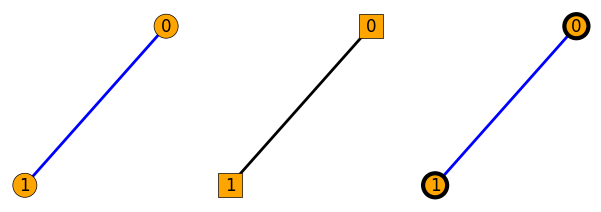

In [13]:
coherent_halves = np.array([optimizer_epr.space.split(g)[0] for g in irreducibles_epr],
                           dtype="int8")
fig, axes = plot_list_of_graphs(coherent_halves, optimizer_epr.space.coherent,
                                node_colors=["orange"] * optimizer_epr.space.num_modes)
plt.show()

## B.2&prime; — EPR source with a forbidden port–port edge (Sec. 7.3)

Same target as B.2, plus one *hardware* constraint: **the two port modes may not
couple to each other**. This is the covariance analogue of the optomechanical
circulator of [AUTOSCATTER's `6_optomechanical_circulator.ipynb`](https://github.com/jlandgr/autoscatter/blob/main/6_optomechanical_circulator.ipynb)
(Sec. VI of [arXiv:2404.14887](https://arxiv.org/abs/2404.14887)).

**With a searchable dissipative colour, the constraint has to be stated twice:**

* `forbidden_couplings=[(0, 1)]` kills the pair's coherent edges — both of them,
  since the Nambu lattice carries two per mode pair.
* It says nothing about a *shared bath* on the same pair. And a shared bath **is**
  a coupling: dissipative hopping, $A_\mathrm{diss}=-\tfrac12 U^\dagger U$ with a
  nonzero off-diagonal.
* The channel-space analogue is `forbidden_supports=[(0, 1)]`.

Forbidding only the coherent half leaves the hardware constraint half-enforced.
The sanity check below measures exactly that gap.


In [14]:
problem = epr_source(local=1.25, correlation=0.75)
kwargs_epr = problem.optimizer_kwargs()

def port_port_floor(label, channel_kwargs):
    optimizer = CollectiveArchitectureOptimizer(
        problem.target, num_auxiliary_modes=0, forbidden_couplings=[(0, 1)],
        make_initial_test=False, seed=0, channel_kwargs=channel_kwargs,
        kwargs_optimization={"num_tests": 20}, **kwargs_epr)
    valid, infos = optimizer.test_graph(optimizer.space.fully_connected())
    print("%-46s valid = %-6s best loss = %.4g"
          % (label, valid, min(info["loss_reached"] for info in infos)))

port_port_floor("coherent edge AND shared bath forbidden",
                dict(max_support=2, private_uncontrolled=False,
                     forbidden_supports=[(0, 1)]))
port_port_floor("only the coherent edge forbidden",
                dict(max_support=2, private_uncontrolled=False))

print()
print("1.25 is the pinned correlation block the device cannot build at all.")
print("Allowing the shared bath drops the floor to ~0.48: dissipative hopping")
print("does correlate the ports -- so the constraint really was half-enforced --")
print("but it cannot finish the job, because a particle-conserving channel is")
print("passive and this target is a *pure* two-mode squeezed state.")

coherent edge AND shared bath forbidden        valid = False  best loss = 1.25


only the coherent edge forbidden               valid = False  best loss = 0.4815

1.25 is the pinned correlation block the device cannot build at all.
Allowing the shared bath drops the floor to ~0.48: dissipative hopping
does correlate the ports -- so the constraint really was half-enforced --
but it cannot finish the job, because a particle-conserving channel is
passive and this target is a *pure* two-mode squeezed state.


### The asymptotic building block

Mode 2 is declared a **bus**: every *coherent* coupling touching it is scaled by
$\sqrt{\Lambda}$ per bus endpoint, so a link to a port scales with $\sqrt{\Lambda}$
and a self term with $\Lambda$. Channel amplitudes are untouched — a bus is a
mediator, not a detector.

Two further restrictions state the hardware honestly: the ports sit on resonance,
and the bus is not pumped degenerately.

With the dissipative colour restricted to one private collected channel per mode,
the two-coloured lattice is **11664 graphs** and the complete descent takes about
**17 minutes**. That is eight times the base spec's 1458, because every mode's
collected rate is now a searchable element rather than a fixed 1.


In [15]:
bus_kwargs = dict(
    forbidden_couplings=[(0, 1)],       # the hardware constraint, coherent half
    forbidden_detunings=(0, 1),         # ports on resonance
    forbidden_onsite_squeezing=(2,),    # the bus is not degenerately pumped
    asymptotic_bus_modes=(2,),          # mode 2 -> asymptotic building block
    bus_cooperativity=1e6,
)
# private channels only: one collected port per mode.  Collective port-bus
# channels are explored separately below -- enumerating them here would put the
# lattice at ~10^5 graphs.
bus_channels = dict(max_support=1, private_uncontrolled=False)

optimizer_bus = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    channel_kwargs=bus_channels, kwargs_optimization={"num_tests": 8},
    **bus_kwargs, **kwargs_epr)

print("two-coloured lattice: %d graphs  (this descent takes ~17 min)"
      % optimizer_bus.space.num_possible_graphs())
libraries_bus = two_library_discover(optimizer_bus, progress=False, verbose=False,
                                     use_certificates=True)
irreducibles_bus = libraries_bus.minimal_valid()
print(libraries_bus.summary())
# Invariant 4 says VALID means a witness exists *and is stored*.  Nothing
# re-checks that once an entry lands, and the graph-reduction step can store a
# reduced graph the witness does not actually satisfy.  Audit the deliverable.
failures = revalidate_valid_library(optimizer_bus, libraries_bus, verbose=True)
print("audit: %d of the irreducibles fail the stored-witness check"
      % len(failures))

two-coloured lattice: 11664 graphs  (this descent takes ~17 min)


valid: 521    invalid: 9514 (certified 1, uncertified 9513)    oracle calls: 153662    escalations: 9546
audit: 0 of the irreducibles fail the stored-witness check



Two irreducible architectures, mirror images of each other — exactly the
degenerate pair the circulator notebook finds.

Each uses **two couplings**: a two-mode-squeezing edge from one port to the bus,
and a beam-splitter edge from the bus to the other port. The bus converts the
squeezing into a correlation between two modes that never touch.


In [16]:
for graph in irreducibles_bus:
    print("[%d elements] %s" % (graph.sum(), ", ".join(optimizer_bus.space.describe(graph))))

best_bus = irreducibles_bus[0]
solution_bus = optimizer_bus.solution_of(best_bus)
V = np.real(np.asarray(optimizer_bus.oracle.covariance(solution_bus["x"], 0.0)))[:4, :4]
print("\nsigma_out at the two ports:")
print(np.round(V, 4))

report = collective_cooperativities(optimizer_bus, best_bus, solution_bus["x"])
print("\ncollected rates  kappa_i = |u_i|^2:")
print("  ", {k: "%.4g" % v for k, v in report["kappa"].items()})
print("cooperativities  C_ij = 4|H_ij|^2/(kappa_i kappa_j):")
print("  ", {k: "%.4g" % v for k, v in report["cooperativities"].items()})
print()
print("kappa_2 = 0 is not a rounding artefact: the search switched the bus's")
print("collected channel *off* entirely.  An uncollected mediator has C = inf")
print("exactly -- the asymptotic limit is attained, not approached.  See below.")

[4 elements] beam-splitter 1-2 (real), two-mode squeezing 0-2 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
[4 elements] beam-splitter 0-2 (real), two-mode squeezing 1-2 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)

sigma_out at the two ports:
[[ 1.25 -0.    0.75  0.  ]
 [-0.    1.25 -0.   -0.75]
 [ 0.75 -0.    1.25  0.  ]
 [ 0.   -0.75  0.    1.25]]

collected rates  kappa_i = |u_i|^2:
   {'kappa_0': '0.755', 'kappa_1': '1.522', 'kappa_2': '0'}
cooperativities  C_ij = 4|H_ij|^2/(kappa_i kappa_j):
   {'C_{0,0}': '4.573e-13', 'C^{BS}_{0,2}': 'inf', 'C^{SQZ}_{0,2}': 'inf', 'C^{BS}_{1,2}': 'inf'}

kappa_2 = 0 is not a rounding artefact: the search switched the bus's
collected channel *off* entirely.  An uncollected mediator has C = inf
exactly -- the asymptotic limit is attained, not approached.  See below.


Both bus architectures with the parameters behind them.

**Read the cooperativities from `collective_cooperativities`, not from
`physical_report`.** The latter reports $C_{ij}=4|H_{ij}|^2$, which is the
cooperativity only in the base spec's normalisation where every $\kappa_i$ is
pinned to 1. Here the collected rate is a free channel amplitude, so

$$C_{ij} = \frac{4|H_{ij}|^{2}}{\kappa_i \kappa_j},$$

and on this architecture the two disagree by five orders of magnitude:
0.42 / 2.44 against the true $7.0\times10^{3}$ / $2.4\times10^{5}$.


In [17]:
for graph in irreducibles_bus:
    solution = optimizer_bus.solution_of(graph)
    if solution is None:
        continue
    report = collective_cooperativities(optimizer_bus, graph, solution["x"])
    kappa = report["kappa"]
    print(", ".join(optimizer_bus.space.describe(graph)))
    print("     kappa            ", {k: "%.4g" % v for k, v in kappa.items()})
    print("     cooperativities  ", {k: "%.4g" % v for k, v in
                                     report["cooperativities"].items()})
    uncollected = [k for k, v in kappa.items() if v == 0.0]
    if uncollected:
        print("     (%s carry no collected channel -> those C are infinite)"
              % ", ".join(uncollected))
    print()

beam-splitter 1-2 (real), two-mode squeezing 0-2 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
     kappa             {'kappa_0': '0.755', 'kappa_1': '1.522', 'kappa_2': '0'}
     cooperativities   {'C_{0,0}': '4.573e-13', 'C^{BS}_{0,2}': 'inf', 'C^{SQZ}_{0,2}': 'inf', 'C^{BS}_{1,2}': 'inf'}
     (kappa_2 carry no collected channel -> those C are infinite)

beam-splitter 0-2 (real), two-mode squeezing 1-2 (real), private controlled particle_conserving channel on [0] (real), private controlled particle_conserving channel on [1] (real)
     kappa             {'kappa_0': '0.0728', 'kappa_1': '0.4144', 'kappa_2': '0'}
     cooperativities   {'C_{0,0}': '2.738e-10', 'C^{BS}_{0,2}': 'inf', 'C_{1,1}': '7.251e-13', 'C^{SQZ}_{1,2}': 'inf'}
     (kappa_2 carry no collected channel -> those C are infinite)



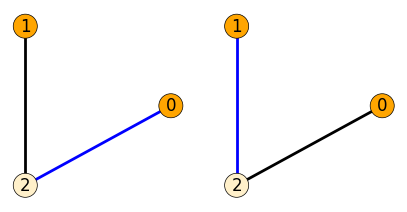

In [18]:
coherent_halves = np.array([optimizer_bus.space.split(g)[0] for g in irreducibles_bus],
                           dtype="int8")
fig, axes = plot_list_of_graphs(coherent_halves, optimizer_bus.space.coherent,
                                node_colors=["orange", "orange", "#FFF0CA"])
plt.show()

### Can a shared bath replace a coherent edge?

The bus architecture spends two couplings: a two-mode-squeezing edge from one port
to the bus, and a beam-splitter edge from the bus to the other.

The beam-splitter is *passive* — and a particle-conserving collective channel is
exactly a passive coupling ($A_\mathrm{diss}=-\tfrac12 U^\dagger U\preceq 0$, pure
dissipative hopping). So it should be able to stand in for that edge, but not for
the squeezing one. Four graphs settle it.


In [19]:
substitution = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    channel_kwargs=dict(max_support=2, private_uncontrolled=False,
                        forbidden_supports=[(0, 1)]),
    kwargs_optimization={"num_tests": 40}, **bus_kwargs, **kwargs_epr)

space = substitution.space
offset = space.num_coherent_slots
slots = space.coherent.slots
tms02 = slots.index(("two_mode_squeezing", 0, 2))
bs12 = slots.index(("beamsplitter", 1, 2))
private = [space.channels.index_of((i,), ChannelClass.PARTICLE_CONSERVING,
                                   Access.CONTROLLED) for i in range(3)]
shared02 = space.channels.index_of((0, 2), ChannelClass.PARTICLE_CONSERVING,
                                   Access.CONTROLLED)
shared12 = space.channels.index_of((1, 2), ChannelClass.PARTICLE_CONSERVING,
                                   Access.CONTROLLED)

def build(coherent=(), channels=()):
    graph = space.empty()
    for slot, value in coherent:
        graph[slot] = value
    for index in private:
        graph[offset + index] = 1
    for slot, value in channels:
        graph[offset + slot] = value
    return graph

cases = [
    ("TMS(0,2) + BS(1,2)            [the bus architecture]",
     build([(tms02, 2), (bs12, 2)])),
    ("TMS(0,2) + shared bath (1,2)  [BS replaced by a bath]",
     build([(tms02, 2)], [(shared12, 2)])),
    ("TMS(0,2) alone, no 1-2 link at all",
     build([(tms02, 2)])),
    ("shared baths only, no coherent edge",
     build([], [(shared02, 2), (shared12, 2)])),
]
for label, graph in cases:
    valid, infos = substitution.test_graph(graph)
    print("%-54s valid = %-6s loss = %.4g"
          % (label, valid, min(info["loss_reached"] for info in infos)))

TMS(0,2) + BS(1,2)            [the bus architecture]   valid = True   loss = 3.996e-13


TMS(0,2) + shared bath (1,2)  [BS replaced by a bath]  valid = True   loss = 9.381e-11
TMS(0,2) alone, no 1-2 link at all                     valid = False  loss = 1.187


shared baths only, no coherent edge                    valid = False  loss = 1.25


The shared bath **does** replace the beam-splitter: same two-coupling count, one
of them now dissipative.

It cannot replace the squeezing edge — two shared baths and no coherent coupling
sit back at the 1.25 floor. A passive element stays passive in either colour.


### The asymptotic block, and what replaced it

**The base notebook's $1/C_\mathrm{bus}$ convergence curve does not carry over
here — there is nothing left to converge.**

The base spec pins $\kappa_i=1$ on *every* mode, the mediator included. A
virtually-occupied bus then exists only as a limit: push
$C_\mathrm{bus}\to\infty$ by scaling the couplings, meet the target only
asymptotically, and watch the error fall as $1/C_\mathrm{bus}$.
`asymptotic_bus_modes` exists to make that limit point representable.

Here the mediator's collected rate is itself a searchable element, and the search
simply switches it **off**: $\kappa_2=0$ in every irreducible above. An
uncollected mediator has $C=4|H|^2/(\kappa_i\kappa_2)=\infty$ *exactly*, so the
limit is attained rather than approached, and the deviation from the target is the
fit residual rather than a $1/C_\mathrm{bus}$ tail.

The cell below checks the limit is not a fragile one: hand the bus a collected
channel, turn its rate up, and see whether the architecture keeps meeting the
target.


In [20]:
local, correlation = 1.25, 0.75
target_V = np.array([[local, 0.0, correlation, 0.0],
                     [0.0, local, 0.0, -correlation],
                     [correlation, 0.0, local, 0.0],
                     [0.0, -correlation, 0.0, local]])

channels_of = optimizer_bus.space.channels
amp = [optimizer_bus.param.channels.slot_u_abs[
           channels_of.index_of((i,), ChannelClass.PARTICLE_CONSERVING,
                                Access.CONTROLLED)][0]
       for i in range(3)]

x_bus = np.asarray(solution_bus["x"]).copy()
kappa_0 = abs(x_bus[amp[0]]) ** 2
print("discovered witness: kappa_2 = %.3g   (bus carries no collected channel)"
      % abs(x_bus[amp[2]]) ** 2)
print("                    loss    = %.3g" % solution_bus["loss_reached"])
print()
print("now give the bus a collected channel and turn its rate up:")
print("   kappa_2/kappa_0      max|sigma_out - target|")
for kappa_2 in [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]:
    y = x_bus.copy()
    y[amp[2]] = np.sqrt(kappa_2)
    V = np.real(np.asarray(optimizer_bus.oracle.covariance(y, 0.0)))[:4, :4]
    print("     %.1e             %.4e" % (kappa_2 / kappa_0, np.abs(V - target_V).max()))

discovered witness: kappa_2 = 0   (bus carries no collected channel)
                    loss    = 1.26e-11

now give the bus a collected channel and turn its rate up:
   kappa_2/kappa_0      max|sigma_out - target|
     0.0e+00             3.3193e-06
     1.3e-06             3.3193e-06
     1.3e-05             3.3192e-06
     1.3e-04             3.3190e-06
     1.3e-03             3.3168e-06
     1.3e-02             3.2942e-06
     1.3e-01             3.1269e-06


The target is met throughout — an uncollected mediator is the cleanest point of a
flat family, not a knife edge.

Dropping the asymptotic block altogether also converges, at well-conditioned
order-one couplings. The block remains the way to represent a genuinely asymptotic
architecture, but this target stopped needing one the moment the mediator's
linewidth became a searchable element.


In [21]:
finite = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1,
    forbidden_couplings=[(0, 1)], forbidden_detunings=(0, 1),
    forbidden_onsite_squeezing=(2,),
    make_initial_test=False, seed=5, channel_kwargs=bus_channels,
    kwargs_optimization={"num_tests": 30, "max_violation_success": 1e-12},
    **kwargs_epr)

valid, infos = finite.test_graph(best_bus)
info = min(infos, key=lambda item: item["loss_reached"])
print("same graph, no asymptotic block:  valid = %s,  loss = %.3g"
      % (valid, info["loss_reached"]))
report = collective_cooperativities(finite, best_bus, info["x"])
print("   kappa           ", {k: "%.4g" % v for k, v in report["kappa"].items()})
print("   cooperativities ", {k: "%.4g" % v for k, v in report["cooperativities"].items()})

resonant = CollectiveArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, forbidden_couplings=[(0, 1)],
    make_initial_test=False, seed=1, channel_kwargs=bus_channels,
    kwargs_optimization={"num_tests": 20, "max_violation_success": 1e-12},
    **kwargs_epr)
valid, infos = resonant.test_graph(resonant.space.fully_connected())
info = min(infos, key=lambda item: item["loss_reached"])
print("\nresonant mediator, full element budget:  valid = %s,  loss = %.3g"
      % (valid, info["loss_reached"]))

same graph, no asymptotic block:  valid = True,  loss = 1.8e-21
   kappa            {'kappa_0': '0.7988', 'kappa_1': '0.1155', 'kappa_2': '0'}
   cooperativities  {'C^{SQZ}_{0,2}': 'inf', 'C^{BS}_{1,2}': 'inf'}



resonant mediator, full element budget:  valid = True,  loss = 6.2e-13
